# Analyse des méthodes de correction du biais de minage de données

## Objectif du notebook

Ce notebook transforme l'analyse EBTA en une **illustration pédagogique exécutable**.

L'objectif est de comprendre comment construire une pipeline qui limite le **biais de minage de données** quand on teste beaucoup de règles de trading.

> **Idée centrale :** plus on teste de règles, plus on augmente la probabilité de trouver un faux gagnant. Le rôle du **WRC**, de la **MCPM**, de l'amélioration **Romano-Wolf** et du **Validation Set** est de séparer le vrai edge du simple hasard.

## Plan

1. Comprendre le problème : le meilleur backtest peut être un imposteur.
2. Simuler un univers de règles sans edge réel.
3. Montrer pourquoi le simple meilleur résultat est trompeur.
4. Implémenter une version pédagogique du **White's Reality Check**.
5. Implémenter une version pédagogique de la **MCPM**.
6. Ajouter une logique **Romano-Wolf simplifiée**.
7. Comparer **Training / Testing / Validation**.
8. Construire une checklist EBTA opérationnelle.


## 1. Le problème : le meilleur backtest n'est pas forcément le meilleur système

Quand on teste une seule règle, une bonne performance passée peut déjà être trompeuse.

Mais quand on teste 100, 1 000 ou 10 000 règles, le problème explose : même si toutes les règles sont nulles, certaines auront l'air excellentes par pur hasard.

On peut résumer le danger ainsi :

$$
\text{Plus } N_{\text{règles}} \text{ augmente, plus } \max(\text{performance}) \text{ augmente par hasard.}
$$

C'est exactement le cœur du **data-mining bias**.

> **Erreur fréquente :** regarder seulement la meilleure equity curve revient à ignorer le cimetière invisible de toutes les règles ratées.


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Paramètres pédagogiques
n_bars = 1_000
n_rules = 500
annualization = 252

# Rendements de marché simulés sans edge prédictif
# On ajoute une légère tendance positive pour illustrer ensuite la détendance.
market_returns = np.random.normal(loc=0.00015, scale=0.01, size=n_bars)

# Règles aléatoires : signaux long/short générés au hasard
signals = np.random.choice([-1, 1], size=(n_bars, n_rules))

# Rendements des règles
rule_returns = signals * market_returns.reshape(-1, 1)

# Performance moyenne annualisée de chaque règle
mean_returns = rule_returns.mean(axis=0) * annualization
best_rule_idx = int(np.argmax(mean_returns))
best_mean_return = mean_returns[best_rule_idx]

print(f"Nombre de règles testées : {n_rules}")
print(f"Meilleure règle trouvée : règle #{best_rule_idx}")
print(f"Rendement moyen annualisé apparent : {best_mean_return:.2%}")


Nombre de règles testées : 500
Meilleure règle trouvée : règle #331
Rendement moyen annualisé apparent : 22.48%


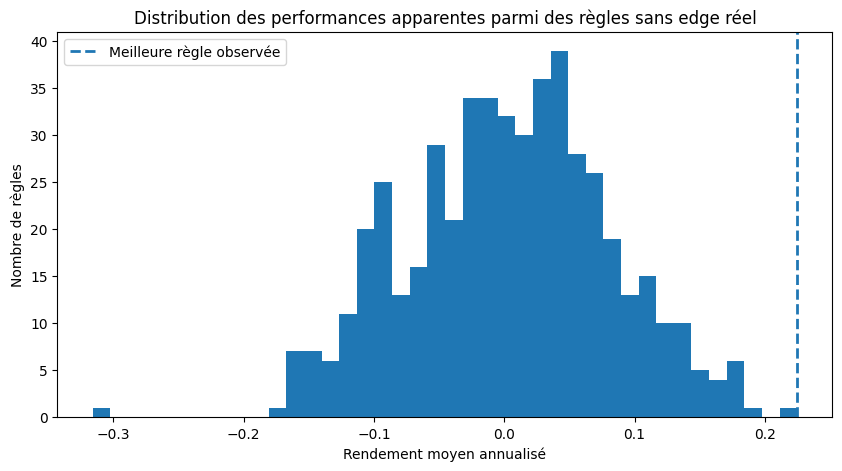

In [15]:
plt.figure(figsize=(10, 5))
plt.hist(mean_returns, bins=40)
plt.axvline(best_mean_return, linestyle='--', linewidth=2, label='Meilleure règle observée')
plt.title('Distribution des performances apparentes parmi des règles sans edge réel')
plt.xlabel('Rendement moyen annualisé')
plt.ylabel('Nombre de règles')
plt.legend()
plt.show()


## 2. Détendance : retirer le profit qui vient du marché lui-même

Dans EBTA, une étape importante consiste à éviter de confondre une règle réellement prédictive avec une règle qui profite simplement du biais moyen du marché.

Une version pédagogique de la **détendance** consiste à retirer la moyenne des rendements du marché :

$$
R^{\text{détendu}}_t = R_t - \bar{R}
$$

Ainsi, une règle doit démontrer qu'elle capte quelque chose au-delà du simple drift moyen.


In [16]:
detrended_market_returns = market_returns - market_returns.mean()
detrended_rule_returns = signals * detrended_market_returns.reshape(-1, 1)

detrended_mean_returns = detrended_rule_returns.mean(axis=0) * annualization
detrended_best_idx = int(np.argmax(detrended_mean_returns))
detrended_best_return = detrended_mean_returns[detrended_best_idx]

print(f"Meilleure règle après détendance : règle #{detrended_best_idx}")
print(f"Rendement annualisé apparent après détendance : {detrended_best_return:.2%}")


Meilleure règle après détendance : règle #331
Rendement annualisé apparent après détendance : 22.77%


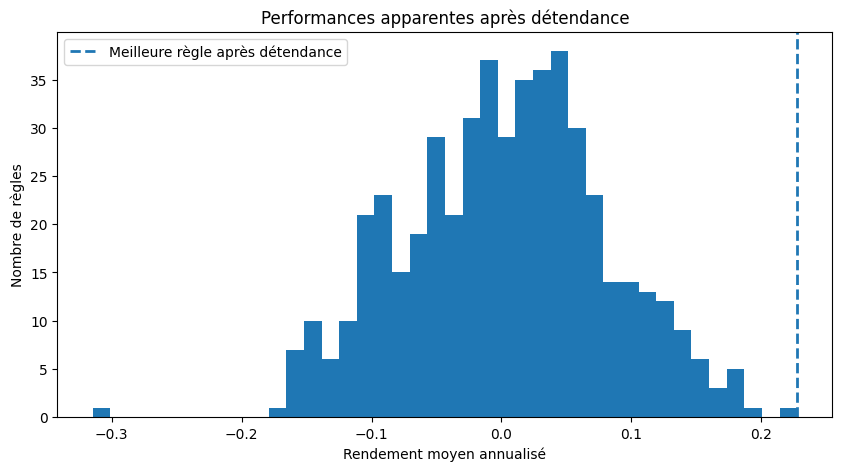

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(detrended_mean_returns, bins=40)
plt.axvline(detrended_best_return, linestyle='--', linewidth=2, label='Meilleure règle après détendance')
plt.title('Performances apparentes après détendance')
plt.xlabel('Rendement moyen annualisé')
plt.ylabel('Nombre de règles')
plt.legend()
plt.show()


## 3. White's Reality Check pédagogique

Le **White's Reality Check** ne demande pas simplement :

> "La meilleure règle est-elle bonne ?"

Il demande plutôt :

> "Dans un monde où aucune règle n'a d'edge, à quel point le meilleur résultat peut-il devenir élevé simplement à cause du hasard ?"

On construit donc une distribution du maximum :

$$
T_b = \max_{i \in \{1, \dots, N\}} \left( \bar{R}_{i,b}^{*} \right)
$$

Puis on compare le meilleur résultat réel à cette distribution.

La **p-value ajustée** devient :

$$
p = \mathbb{P}(T_b \geq T_{\text{observé}})
$$

Si cette p-value est grande, la meilleure règle n'est pas impressionnante : le hasard aurait pu faire aussi bien.


In [18]:
def whites_reality_check(rule_returns, n_boot=1_000, seed=123):
    """Version pédagogique du WRC par bootstrap des lignes temporelles."""
    rng = np.random.default_rng(seed)
    n_obs, n_rules = rule_returns.shape
    observed_rule_means = rule_returns.mean(axis=0)
    observed_max = observed_rule_means.max()

    boot_max_stats = np.empty(n_boot)
    centered = rule_returns - rule_returns.mean(axis=0, keepdims=True)

    for b in range(n_boot):
        idx = rng.integers(0, n_obs, size=n_obs)
        sample = centered[idx, :]
        boot_max_stats[b] = sample.mean(axis=0).max()

    p_value = np.mean(boot_max_stats >= observed_max)
    return observed_max, boot_max_stats, p_value

observed_max, boot_max_stats, wrc_pvalue = whites_reality_check(detrended_rule_returns, n_boot=1_000)

print(f"Statistique observée max moyenne quotidienne : {observed_max:.6f}")
print(f"P-value WRC ajustée : {wrc_pvalue:.4f}")
print("Conclusion :", "significatif" if wrc_pvalue < 0.05 else "non significatif")


Statistique observée max moyenne quotidienne : 0.000904
P-value WRC ajustée : 0.5490
Conclusion : non significatif


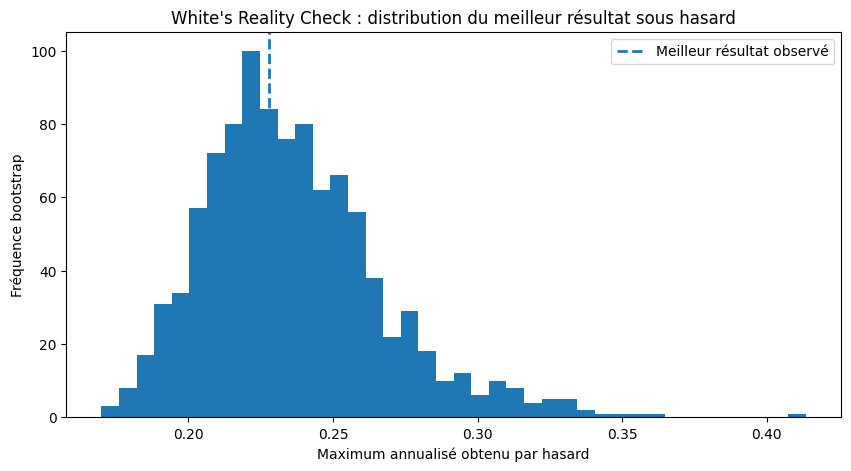

In [19]:
plt.figure(figsize=(10, 5))
plt.hist(boot_max_stats * annualization, bins=40)
plt.axvline(observed_max * annualization, linestyle='--', linewidth=2, label='Meilleur résultat observé')
plt.title("White's Reality Check : distribution du meilleur résultat sous hasard")
plt.xlabel('Maximum annualisé obtenu par hasard')
plt.ylabel('Fréquence bootstrap')
plt.legend()
plt.show()


## 4. MCPM pédagogique : casser l'association signal/rendement

La **Monte Carlo Permutation Method** repose sur une idée simple : si une règle possède un vrai pouvoir prédictif, ce pouvoir dépend de l'association correcte entre ses signaux et les rendements du marché.

On détruit donc cette association en mélangeant les rendements ou les signaux.

L'hypothèse nulle devient :

$$
H_0 : \text{les signaux ne prédisent pas les rendements.}
$$

Si le meilleur résultat observé n'est pas supérieur aux meilleurs résultats obtenus après permutation, alors il n'y a pas de preuve robuste d'edge.


In [20]:
def mc_permutation_method(signals, returns, n_perm=1_000, seed=456):
    """Version pédagogique de la MCPM : permutation des rendements."""
    rng = np.random.default_rng(seed)
    observed_returns = signals * returns.reshape(-1, 1)
    observed_max = observed_returns.mean(axis=0).max()

    perm_max_stats = np.empty(n_perm)
    for b in range(n_perm):
        permuted_returns = rng.permutation(returns)
        perm_rule_returns = signals * permuted_returns.reshape(-1, 1)
        perm_max_stats[b] = perm_rule_returns.mean(axis=0).max()

    p_value = np.mean(perm_max_stats >= observed_max)
    return observed_max, perm_max_stats, p_value

mcpm_observed, mcpm_stats, mcpm_pvalue = mc_permutation_method(signals, detrended_market_returns, n_perm=1_000)

print(f"P-value MCPM ajustée : {mcpm_pvalue:.4f}")
print("Conclusion :", "significatif" if mcpm_pvalue < 0.05 else "non significatif")


P-value MCPM ajustée : 0.5850
Conclusion : non significatif


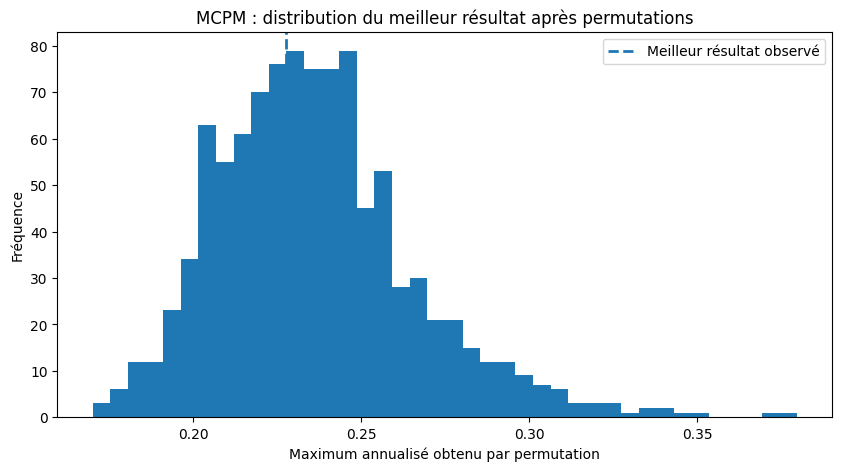

In [21]:
plt.figure(figsize=(10, 5))
plt.hist(mcpm_stats * annualization, bins=40)
plt.axvline(mcpm_observed * annualization, linestyle='--', linewidth=2, label='Meilleur résultat observé')
plt.title('MCPM : distribution du meilleur résultat après permutations')
plt.xlabel('Maximum annualisé obtenu par permutation')
plt.ylabel('Fréquence')
plt.legend()
plt.show()


## 5. Romano-Wolf simplifié : ne pas laisser les règles perdantes tuer la puissance

Le problème pointé par Hansen puis amélioré par Romano-Wolf est lié à la **puissance statistique**.

Dans un univers contenant beaucoup de règles médiocres, certaines méthodes globales deviennent trop conservatrices. Elles contrôlent bien les faux positifs, mais elles augmentent le risque de rater une vraie règle.

En version pédagogique, une logique **stepwise** consiste à :

1. Tester l'ensemble des règles.
2. Identifier les règles clairement non compétitives.
3. Retester un sous-ensemble plus pertinent.
4. Garder le contrôle du risque de faux positif tout en améliorant la puissance.

> **Attention :** cette version est une approximation pédagogique, pas une implémentation académique complète de Romano-Wolf.


In [27]:
def simplified_stepwise_wrc(rule_returns, keep_quantile=0.80, n_boot=1_000):
    """Approche pédagogique : garder seulement les règles dans le top quantile observé."""
    means = rule_returns.mean(axis=0)
    threshold = np.quantile(means, keep_quantile)
    selected = means >= threshold

    observed_max, boot_stats, p_value = whites_reality_check(rule_returns[:, selected], n_boot=n_boot, seed=789)

    return {
        'n_initial_rules': rule_returns.shape[1],
        'n_selected_rules': int(selected.sum()),
        'threshold_daily_mean': threshold,
        'observed_max': observed_max,
        'boot_stats': boot_stats,
        'p_value': p_value,
        'selected_mask': selected
    }

rw_result = simplified_stepwise_wrc(detrended_rule_returns, keep_quantile=0.80, n_boot=1_000)

print(f"Règles initiales : {rw_result['n_initial_rules']}")
print(f"Règles conservées dans l'étape simplifiée : {rw_result['n_selected_rules']}")
print(f"P-value WRC stepwise simplifiée : {rw_result['p_value']:.4f}")


Règles initiales : 500
Règles conservées dans l'étape simplifiée : 100
P-value WRC stepwise simplifiée : 0.1540


## 6. Training / Testing / Validation : l'examen final surprise

La séparation en trois segments répond à une réalité pratique : le chercheur modifie souvent sa règle après avoir vu un échec.

Cette modification peut contaminer le test.

La structure stricte devient :

| Segment | Rôle | Danger si mal utilisé |
|---|---:|---|
| **Training** | Construire les règles | Sur-optimisation |
| **Testing** | Choisir entre variantes | Contamination par itérations répétées |
| **Validation** | Estimation finale non biaisée | Perte de virginité si consulté trop tôt |

La règle d'or est simple :

> Le **Validation Set** ne sert pas à améliorer la règle. Il sert à juger la règle.


In [ ]:
# Créons une simulation avec une seule règle qui possède un petit edge réel,
# puis beaucoup de règles sans edge.
np.random.seed(7)
n_bars = 1_500
n_noise_rules = 499

returns = np.random.normal(0, 0.01, n_bars)

# Signal avec léger pouvoir prédictif : corrélé au signe du rendement avec bruit.
true_signal = np.where(returns + np.random.normal(0, 0.015, n_bars) > 0, 1, -1)
noise_signals = np.random.choice([-1, 1], size=(n_bars, n_noise_rules))
all_signals = np.column_stack([true_signal, noise_signals])
all_rule_returns = all_signals * returns.reshape(-1, 1)

# Split 50/25/25
train_end = int(0.50 * n_bars)
test_end = int(0.75 * n_bars)

train = all_rule_returns[:train_end]
test = all_rule_returns[train_end:test_end]
validation = all_rule_returns[test_end:]

# Sélection sur train
train_means = train.mean(axis=0)
selected_on_train = int(np.argmax(train_means))

# Choix final sur testing parmi le top 20 train
top20_train = np.argsort(train_means)[-20:]
test_means_top20 = test[:, top20_train].mean(axis=0)
selected_final = int(top20_train[np.argmax(test_means_top20)])

summary = pd.DataFrame({
    'segment': ['Training', 'Testing', 'Validation'],
    'performance_annualisée': [
        all_rule_returns[:train_end, selected_final].mean() * annualization,
        all_rule_returns[train_end:test_end, selected_final].mean() * annualization,
        all_rule_returns[test_end:, selected_final].mean() * annualization,
    ]
})

print(f"Règle avec edge réel : #0")
print(f"Règle sélectionnée après train/test : #{selected_final}")
display(summary)


Règle avec edge réel : #0
Règle sélectionnée après train/test : #0


,segment,performance_annualisée
0,Training,1.145656
1,Testing,0.901701
2,Validation,1.061387


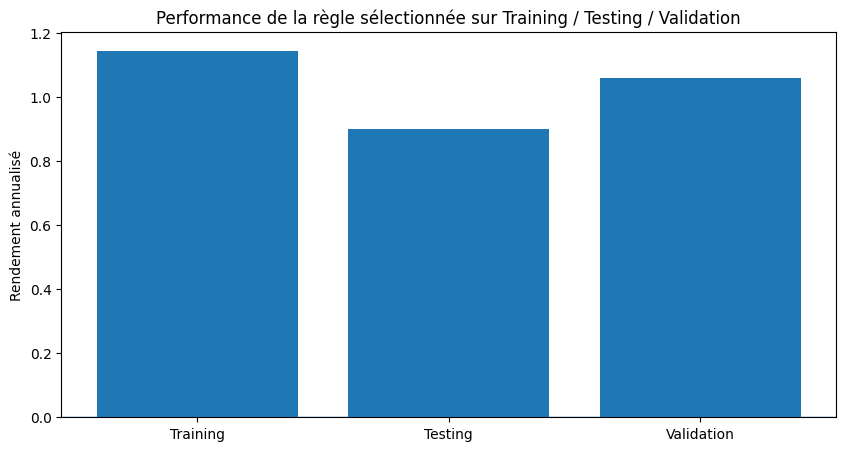

In [29]:
plt.figure(figsize=(10, 5))
plt.bar(summary['segment'], summary['performance_annualisée'])
plt.axhline(0, linewidth=1)
plt.title('Performance de la règle sélectionnée sur Training / Testing / Validation')
plt.ylabel('Rendement annualisé')
plt.show()


## 7. Markowitz/Xu : utile comme repère, pas comme verdict final

L'idée de Markowitz/Xu est de corriger la performance du meilleur candidat en tenant compte du fait qu'il a été sélectionné parmi beaucoup de règles.

En simplifiant fortement, l'intuition est :

$$
\text{Performance corrigée} = \text{Performance observée} - \text{pénalité de minage}
$$

Mais cette pénalité dépend de paramètres difficiles à estimer correctement :

- nombre de règles réellement indépendantes ;
- variance des rendements ;
- corrélation entre règles ;
- nombre d'observations ;
- structure du processus de recherche.

C'est pourquoi, dans une pipeline moderne, cette approche peut servir de **repère rapide**, mais pas de preuve finale.


In [30]:
def crude_mining_penalty(rule_returns):
    """Correction très approximative inspirée de l'idée de pénalité de sélection."""
    n_obs, n_rules = rule_returns.shape
    sigma = rule_returns.mean(axis=0).std(ddof=1)
    penalty = sigma * np.sqrt(2 * np.log(n_rules))
    observed_best = rule_returns.mean(axis=0).max()
    adjusted_best = observed_best - penalty
    return observed_best, penalty, adjusted_best

observed_best, penalty, adjusted_best = crude_mining_penalty(detrended_rule_returns)

print(f"Meilleur rendement quotidien observé : {observed_best:.6f}")
print(f"Pénalité approximative de minage : {penalty:.6f}")
print(f"Meilleur rendement quotidien ajusté : {adjusted_best:.6f}")
print(f"Meilleur rendement annualisé ajusté : {adjusted_best * annualization:.2%}")


Meilleur rendement quotidien observé : 0.000904
Pénalité approximative de minage : 0.001093
Meilleur rendement quotidien ajusté : -0.000189
Meilleur rendement annualisé ajusté : -4.76%


## 8. Pipeline EBTA opérationnelle

Voici la pipeline sous forme de chaîne de décision :

| Étape | Question | Outil |
|---|---|---|
| **1. Détendance** | Le profit vient-il seulement du drift du marché ? | Rendements détendus |
| **2. Recherche contrôlée** | Le meilleur résultat dépasse-t-il ce que le hasard peut produire ? | **WRC / MCPM** |
| **3. Puissance du test** | Le test est-il trop conservateur à cause des règles médiocres ? | **Romano-Wolf stepwise** |
| **4. Validation finale** | Le gagnant survit-il sur une donnée vierge ? | **Validation Set** |
| **5. Décision** | Peut-on considérer la règle comme candidate sérieuse ? | Checklist EBTA |

> **L'Eurêka final :** la vraie question n'est pas "ai-je trouvé une belle equity curve ?". La vraie question est "cette equity curve reste-t-elle exceptionnelle après avoir tenu compte de toutes les tentatives invisibles ?".


In [31]:
def ebta_decision_report(wrc_pvalue, mcpm_pvalue, validation_return, alpha=0.05):
    checks = {
        'WRC significatif': wrc_pvalue < alpha,
        'MCPM significatif': mcpm_pvalue < alpha,
        'Validation positive': validation_return > 0,
    }
    decision = all(checks.values())
    return pd.DataFrame({
        'test': list(checks.keys()),
        'réussite': list(checks.values())
    }), decision

validation_return = summary.loc[summary['segment'] == 'Validation', 'performance_annualisée'].iloc[0]
report, decision = ebta_decision_report(wrc_pvalue, mcpm_pvalue, validation_return)

display(report)
print("Décision EBTA :", "candidate sérieuse" if decision else "à rejeter ou à retravailler")


,test,réussite
0,WRC significatif,False
1,MCPM significatif,False
2,Validation positive,True


Décision EBTA : à rejeter ou à retravailler


## 9. Limites et erreurs fréquentes

### Limites

- Le **WRC** ne garantit pas le profit futur. Il indique seulement que la meilleure performance passée est difficile à expliquer par le hasard du minage.
- La **MCPM** dépend de la validité de la procédure de permutation. Elle doit préserver ce qui doit être préservé et casser uniquement l'association prédictive testée.
- L'amélioration **Romano-Wolf** augmente la puissance, mais ne crée pas un edge quand le signal est absent.
- Le **Validation Set** peut devenir contaminé si on le consulte, puis qu'on modifie la règle.

### Erreurs fréquentes

- Utiliser un **t-test classique** sur le meilleur backtest parmi des centaines de règles.
- Croire qu'une règle est bonne parce que son **backtest brut** est élevé.
- Oublier de compter toutes les règles testées, y compris les variantes abandonnées.
- Transformer progressivement l'**OOS** en nouveau segment d'entraînement.
- Confondre **significativité statistique** et **tradabilité réelle** : coûts, slippage, capacité, latence et drawdown restent à tester.


## 10. À retenir absolument

- Le **biais de minage** vient du fait que le meilleur résultat est choisi après avoir testé beaucoup d'idées.
- Le **WRC** et la **MCPM** testent le meilleur candidat contre une distribution du meilleur résultat possible sous hasard.
- La version **Romano-Wolf** cherche à garder la rigueur tout en améliorant la **puissance statistique**.
- Le **Validation Set** reste indispensable pour obtenir une estimation finale plus honnête.
- La méthode **Markowitz/Xu** peut aider à raisonner, mais elle ne remplace pas une simulation de significativité.

> **Conclusion EBTA :** le minage de données n'est pas interdit. Il doit être discipliné. Une règle ne mérite l'attention que si elle survit à la détendance, aux tests globaux ajustés, puis à une validation réellement vierge.


## Annexe — Texte source fourni

Le texte ci-dessous est conservé comme annexe pour assurer la traçabilité du notebook.


# ANALYSE DES MÉTHODES DE CORRECTION DU BIAIS DE MINAGE DE DONNÉES

## Référence
*   **Titre :** *Solutions: Dealing with the Data-Mining Bias* ; *Out-of-Sample Testing* ; *Randomization Methods* ; *Case Study Results*.
*   **Chapitre :** Chapitre 6 (p. 320-330) et Chapitre 9 (p. 457-458).
*   **Thème principal :** Hiérarchisation et intégration des remèdes au biais de sélection.

## Idées clés
1.  **La supériorité des méthodes de randomisation** — Le *White’s Reality Check* (WRC) et la MCPM sont les outils les plus rigoureux car ils utilisent tout l'historique sans gaspiller de données.
2.  **L'amélioration Romano-Wolf comme standard** — Cette modification est indispensable pour maximiser la puissance du test et éviter de rejeter de bonnes règles (Erreur de Type II).
3.  **L'approche à trois segments** — Pour les règles complexes (optimisation de la complexité), la séparation en *Entraînement / Test / Validation* est la seule méthode fournissant une estimation non biaisée.
4.  **Le caractère indicatif de Markowitz/Xu** — Cette méthode est jugée approximative et moins fiable que les tests de significativité par simulation.

## Citation directe
> “Out-of-sample testing involves excluding one or more subsets of the historical data from the data mining... The selected rule’s performance on the data that was insulated from mining operations provides an unbiased estimate of its expected return.”

*Cette citation souligne que le seul moyen d'obtenir une vérité statistique est de tester le "gagnant" sur une donnée qui n'a jamais servi à le choisir.*

## Vision macro
L'enjeu est de construire un "entonnoir de vérité". David Aronson explique que le minage de données est une méthode de recherche productive mais dangereuse. L'objectif de l'EBTA n'est pas d'éliminer le minage, mais de le discipliner par une pipeline de validation. L'approche la plus fiable consiste à combiner la puissance des tests de significativité globaux (WRC/MCPM) avec la prudence pragmatique des données hors-échantillon (OOS). La fiabilité dépend de la capacité de la pipeline à résister au "snooping" (furetage) incessant du chercheur.

## Vision micro
Le fonctionnement d'une pipeline EBTA optimale repose sur l'articulation de ces mécanismes :

1.  **Phase de Prétraitement (Détendance) :** Avant tout test, soustraire la tendance moyenne du marché pour s'assurer que le profit ne vient pas d'un simple biais de position.
2.  **Phase de Recherche et Filtrage (WRC/MCPM Romano-Wolf) :** Tester des milliers de règles sur l'ensemble des données. Appliquer le WRC pour calculer une p-value ajustée qui tient compte du nombre total de tentatives ($N$ rules). Si la p-value Romano-Wolf est > 0,05, la recherche s'arrête : tout est bruit.
3.  **Phase de Validation Finale (Validation Set) :** Si la règle survit au WRC, elle est appliquée à un segment de données "vierge" (le segment de validation). C'est ce chiffre, et non celui du backtest, qui sert d'estimation de profit futur.

## Exemples du livre
*   **L'échec de l'étude de cas (S&P 500) :** Aronson a testé 6 402 règles. Bien que certaines affichaient des profits bruts records, l'utilisation du WRC et de la MCPM a révélé qu'aucune n'était statistiquement significative une fois le biais de minage corrigé. Sans ces tests, il aurait conclu par erreur à l'existence d'un "edge".
*   **Le violoniste de l'orchestre :** Pour illustrer la fiabilité, Aronson compare un test à faible hasard (musique) où l'OOS est inutile, au trading (fort hasard) où l'OOS et la randomisation sont les seuls moyens de ne pas être trompé par un "imposteur chanceux".

## Résumé simplifié
Les méthodes les plus fiables sont le **White’s Reality Check (version Romano-Wolf)** et le **Test de Validation** (données jamais vues). Pour réussir, vous devez créer une chaîne de montage : d'abord, nettoyez vos données (Détendance), ensuite passez vos milliers d'idées au scanner (WRC), et enfin, vérifiez que le gagnant réussit un examen final surprise (Validation). La méthode de Markowitz/Xu est superflue car elle est trop imprécise comparée aux simulations informatiques modernes.

## Actions concrètes
*   **À mettre dans la pipeline :**
    *   Détendance systématique des rendements.
    *   Utilisation du WRC ou MCPM avec l'amélioration Romano-Wolf (Stepwise).
    *   Séparation stricte en trois segments (Training / Testing / Validation).
*   **À éviter / Superflux :**
    *   Ne pas se fier au facteur Markowitz/Xu seul.
    *   Bannir les tests de significativité ordinaires (t-test) pour le minage.
    *   Éviter les tests OOS simples si vous avez l'intention de modifier la règle après un échec (contamination).

## Limites et erreurs fréquentes
### Limites
*   “Ce passage ne prouve pas que le WRC garantit le profit futur.” Il prouve seulement que le profit passé n'est pas dû au hasard du minage.
*   L'amélioration Romano-Wolf ne peut pas créer de la significativité là où il n'y a que du bruit pur.

### Erreurs fréquentes
*   **Penser que l'OOS suffit :** Aronson montre que si l'on teste trop de règles en "In-Sample", on finit par "polluer" l'OOS par simple probabilité.
*   **Ignorer la Détendance :** Croire qu'une règle est bonne alors qu'elle ne fait que profiter d'un marché qui monte naturellement.

## À retenir absolument
*   Le **WRC (Romano-Wolf)** est la méthode statistique la plus robuste.
*   La pipeline idéale : **Détendance -> WRC Romano-Wolf -> Validation Set**.
*   La méthode **Markowitz/Xu** est accessoire et non prioritaire.
*   Une règle **complexe** sans segment de **Validation** est condamnée au surapprentissage.
*   Si le **WRC** échoue, aucune autre méthode ne peut sauver la stratégie.

J'ai terminé l'analyse des méthodes d'élimination du biais de minage selon le protocole EBTA.
